In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\rahul\Downloads\archive\retail_sales_dataset.csv")

In [3]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [4]:
df.shape

(1000, 9)

In [5]:
df.dtypes

Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
num_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
summary_stats = df[num_cols].agg(['mean', 'median', lambda x: x.mode()[0], 'std']).rename(index={'<lambda>': 'mode'}).T
summary_stats

,mean,median,mode,std
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
print("Min date:", df['Date'].min(), "Max date:", df['Date'].max())

# Monthly sales
monthly_sales = df.set_index('Date').resample('ME')['Total Amount'].sum()
print("\nMonthly sales:")
print(monthly_sales)

# Quarterly sales
quarterly_sales = df.set_index('Date').resample('QE')['Total Amount'].sum()
print("\nQuarterly sales:")
print(quarterly_sales)

Min date: 2023-01-01 00:00:00 Max date: 2024-01-01 00:00:00

Monthly sales:
Date
2023-01-31    35450
2023-02-28    44060
2023-03-31    28990
2023-04-30    33870
2023-05-31    53150
2023-06-30    36715
2023-07-31    35465
2023-08-31    36960
2023-09-30    23620
2023-10-31    46580
2023-11-30    34920
2023-12-31    44690
2024-01-31     1530
Freq: ME, Name: Total Amount, dtype: int64

Quarterly sales:
Date
2023-03-31    108500
2023-06-30    123735
2023-09-30     96045
2023-12-31    126190
2024-03-31      1530
Freq: QE-DEC, Name: Total Amount, dtype: int64


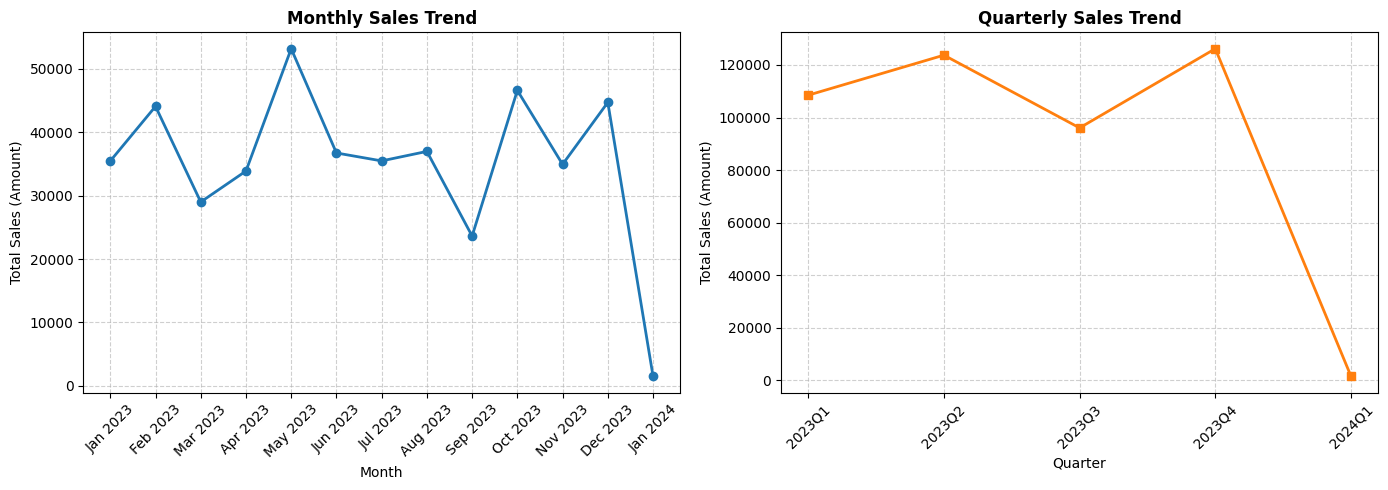

In [9]:
import matplotlib.pyplot as plt

# Prepare data
monthly = df.set_index('Date').resample('ME')['Total Amount'].sum()
quarterly = df.set_index('Date').resample('QE')['Total Amount'].sum()

# Convert index to readable string labels
monthly_labels = monthly.index.strftime('%b %Y')
quarterly_labels = quarterly.index.to_period('Q').astype(str)

plt.figure(figsize=(14, 5))

# Monthly plot
plt.subplot(1, 2, 1)
plt.plot(monthly_labels, monthly.values, marker='o', color='#1f77b4', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=12, fontweight='bold')
plt.xlabel('Month', fontsize=10)
plt.ylabel('Total Sales (Amount)', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

# Quarterly plot
plt.subplot(1, 2, 2)
plt.plot(quarterly_labels, quarterly.values, marker='s', color='#ff7f0e', linewidth=2)
plt.title('Quarterly Sales Trend', fontsize=12, fontweight='bold')
plt.xlabel('Quarter', fontsize=10)
plt.ylabel('Total Sales (Amount)', fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('sales_trends.png', dpi=300)
plt.show()

In [10]:
# Age analysis & Age groups
print("\nAge Summary:")
print(df['Age'].describe())


Age Summary:
count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64


In [11]:
print("Min age:", df['Age'].min(), "Max age:", df['Age'].max())

Min age: 18 Max age: 64


In [12]:
# Gender breakdown
gender_counts = df['Gender'].value_counts()
gender_pct = df['Gender'].value_counts(normalize=True) * 100
gender_summary = pd.DataFrame({'Count': gender_counts, 'Percentage (%)': gender_pct.round(2)})
print("Gender Breakdown:")
print(gender_summary)

# Age Binning & Grouping
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Age Group Breakdown Table
age_summary = pd.DataFrame({
    'Count': df['Age Group'].value_counts().sort_index(),
    'Percentage (%)': (df['Age Group'].value_counts(normalize=True).sort_index() * 100).round(2),
    'Avg Spend': df.groupby('Age Group')['Total Amount'].mean().round(2),
    'Total Spend': df.groupby('Age Group')['Total Amount'].sum()
})

# Cross-tabulation (Age Group vs Gender)
cross_tab = pd.crosstab(df['Age Group'], df['Gender'], margins=True)

print("\n--- Age Group Summary ---")
print(age_summary)
print("\n--- Age Group vs Gender Crosstab ---")
print(cross_tab)

Gender Breakdown:
        Count  Percentage (%)
Gender                       
Female    510            51.0
Male      490            49.0

--- Age Group Summary ---
           Count  Percentage (%)  Avg Spend  Total Spend
Age Group                                               
18-25        169            16.9     500.30        84550
26-35        205            20.5     480.39        98480
36-45        202            20.2     454.80        91870
46-55        229            22.9     439.69       100690
56-65        195            19.5     412.36        80410

--- Age Group vs Gender Crosstab ---
Gender     Female  Male   All
Age Group                    
18-25          81    88   169
26-35         107    98   205
36-45         107    95   202
46-55         119   110   229
56-65          96    99   195
All           510   490  1000


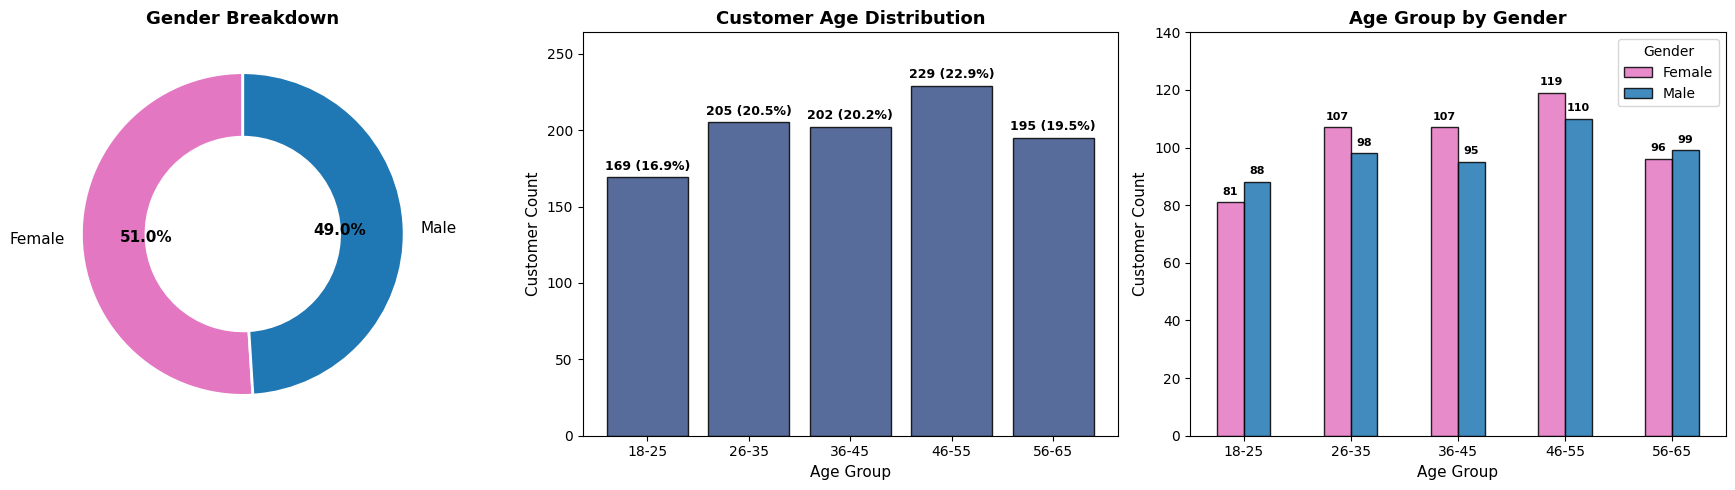

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Gender Distribution (Donut Chart)
colors_gender = ['#e377c2', '#1f77b4']
gender_counts = df['Gender'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors_gender,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Gender Breakdown', fontsize=13, fontweight='bold')

# Plot 2: Age Group Distribution (Bar Chart)
age_group_counts = df['Age Group'].value_counts().sort_index()
bars = axes[1].bar(age_group_counts.index, age_group_counts.values, color='#3b528b', edgecolor='black', alpha=0.85)
axes[1].set_title('Customer Age Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=11)
axes[1].set_ylabel('Customer Count', fontsize=11)
axes[1].set_ylim(0, max(age_group_counts.values) + 35)
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 3, f'{yval} ({yval/10:.1f}%)', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Age Group by Gender (Grouped Bar Chart)
cross_tab_plot = pd.crosstab(df['Age Group'], df['Gender'])
cross_tab_plot.plot(kind='bar', ax=axes[2], color=['#e377c2', '#1f77b4'], edgecolor='black', alpha=0.85, rot=0)
axes[2].set_title('Age Group by Gender', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Age Group', fontsize=11)
axes[2].set_ylabel('Customer Count', fontsize=11)
axes[2].legend(title='Gender', frameon=True)
axes[2].set_ylim(0, 140)

for p in axes[2].patches:
    h = p.get_height()
    if h > 0:
        axes[2].annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h + 2),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Product Category Revenue & Volume Summary
category_summary = df.groupby('Product Category').agg(
    Units_Sold=('Quantity', 'sum'),
    Total_Revenue=('Total Amount', 'sum'),
    Avg_Price_Per_Unit=('Price per Unit', 'mean'),
    Avg_Order_Value=('Total Amount', 'mean'),
    Transactions=('Transaction ID', 'count')
).sort_values(by='Total_Revenue', ascending=False)

print("Product Category Performance:")
display(category_summary)

# Top 10 Best-Selling Product Tiers (Category + Price Point)
product_tiers = df.groupby(['Product Category', 'Price per Unit']).agg(
    Units_Sold=('Quantity', 'sum'),
    Total_Revenue=('Total Amount', 'sum'),
    Order_Count=('Transaction ID', 'count')
).reset_index()

product_tiers['Product Tier'] = (
    product_tiers['Product Category'] + ' (₹' + product_tiers['Price per Unit'].astype(str) + ')'
)
top_10_products = product_tiers.sort_values(by='Units_Sold', ascending=False).head(10)

print("\nTop 10 Best-Selling Product Tiers:")
display(top_10_products[['Product Tier', 'Units_Sold', 'Total_Revenue', 'Order_Count']])

Product Category Performance:


,Units_Sold,Total_Revenue,Avg_Price_Per_Unit,Avg_Order_Value,Transactions
Product Category,,,,,
Electronics,849,156905,181.900585,458.786550,342
Clothing,894,155580,174.287749,443.247863,351
Beauty,771,143515,184.055375,467.475570,307



Top 10 Best-Selling Product Tiers:


,Product Tier,Units_Sold,Total_Revenue,Order_Count
8,Clothing (₹300),193,57900,72
7,Clothing (₹50),189,9450,75
5,Clothing (₹25),184,4600,75
13,Electronics (₹300),183,54900,72
10,Electronics (₹25),181,4525,72
12,Electronics (₹50),175,8750,69
6,Clothing (₹30),171,5130,65
2,Beauty (₹50),170,8500,67
14,Electronics (₹500),169,84500,67
4,Beauty (₹500),169,84500,68


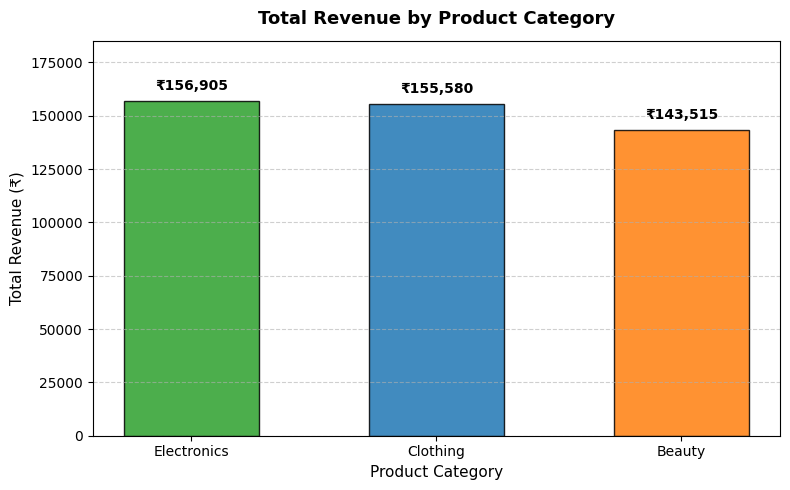

In [15]:
# Revenue by Product Category
cat_rev = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e']
bars = plt.bar(cat_rev.index, cat_rev.values, color=colors, edgecolor='black', alpha=0.85, width=0.55)

plt.title('Total Revenue by Product Category', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Total Revenue (₹)', fontsize=11)
plt.ylim(0, max(cat_rev.values) * 1.18)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 3500, f'₹{yval:,.0f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

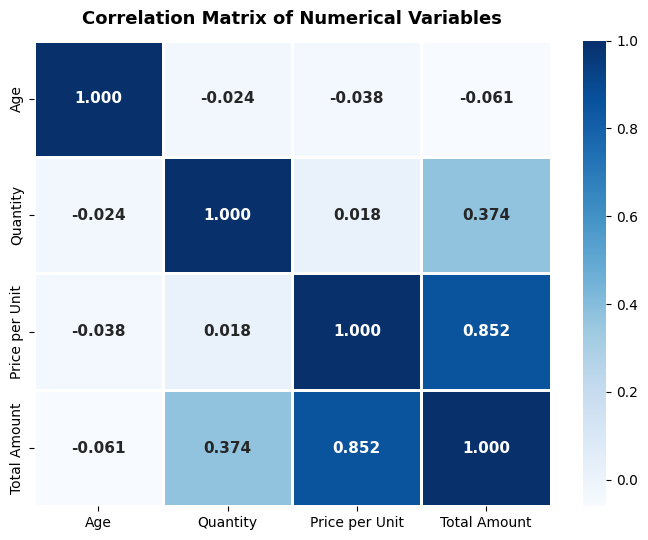

In [16]:
import seaborn as sns

corr_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', 
            linewidths=1, linecolor='white', cbar=True,
            annot_kws={"size": 11, "weight": "bold"})

plt.title('Correlation Matrix of Numerical Variables', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

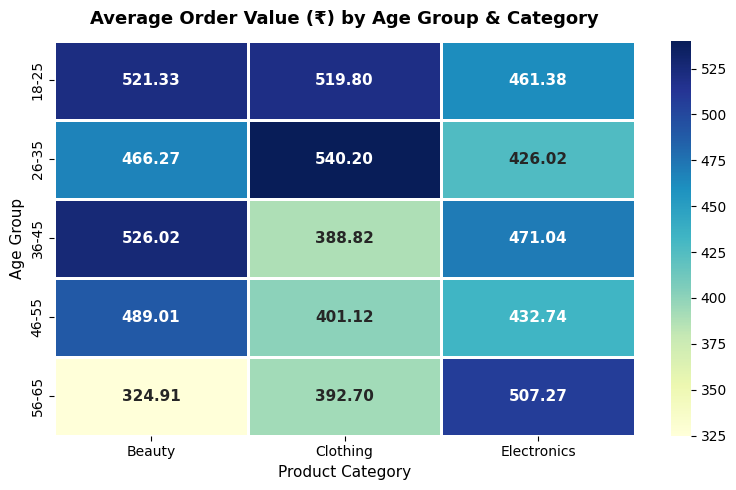

In [17]:
# Create Age Groups
df['Age Group'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 65], 
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

# Pivot Table for Average Order Value (₹)
age_cat_pivot = df.pivot_table(index='Age Group', columns='Product Category', 
                               values='Total Amount', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(age_cat_pivot, annot=True, fmt='.2f', cmap='YlGnBu', 
            linewidths=1, linecolor='white', 
            annot_kws={"size": 11, "weight": "bold"})

plt.title('Average Order Value (₹) by Age Group & Category', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Age Group', fontsize=11)
plt.tight_layout()
plt.show()